## Neural Networks and Deep Learning Project

The goal of the project is to re-implement a famous Convolutionnal Architecture from scratch to showcase the resnet architecture against conventionnal convolution architecture.

### 0. Importing the libraries

In [ ]:
from fastai.vision.all import *
import torch
import torch.nn as nn
from torch import tensor
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
import csv
import os
import pandas as pd

In [ ]:
configs = {
    18 : [2, 2, 2, 2],
    34 : [3, 4, 6, 3],
    50 : [3, 4, 6, 3],
    101: [3, 4, 23, 3],
    152: [3, 8, 36, 3]
}
#Sizes of the differents layers with different sizes

In [6]:
#For the classes, since i am working with Imagenette 160 I implemented a dictionnary to see the class that corresponds to the number (it won't work with another dataset)
id_to_english = {
    "n01440764": "Tench",
    "n02102040": "English springer",
    "n02979186": "Cassette player",
    "n03000684": "Chain saw",
    "n03028079": "Church",
    "n03394916": "French horn",
    "n03417042": "Garbage truck",
    "n03425413": "Gas pump",
    "n03445777": "Golf ball",
    "n03888257": "Parachute"
}
def get_name_from_id(class_id):
    """Return the classe's name if found in the dictionnary """
    return id_to_english.get(class_id, f"Unknown ({class_id})")

In [7]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


### 1.1 Loading the dataset
Before working on our model, we will start by loading the dataset from Imagenette using FASTAI for the loading and data-augmentation.

In [8]:
def get_data(url, presize, resize):
    path = untar_data(url)
    return DataBlock(
        blocks=(ImageBlock, CategoryBlock), get_items=get_image_files,
        splitter=GrandparentSplitter(valid_name='val'),
        get_y=parent_label, item_tfms=Resize(presize),
        batch_tfms=[*aug_transforms(min_scale=0.5, size=resize),
                    Normalize.from_stats(*imagenet_stats)],
    ).dataloaders(path, bs=128)

dls = get_data(URLs.IMAGENETTE_320, 320, 224) #128 avant


In [9]:
x, y = dls.one_batch()
print(x.shape)
print(f"Number of classes : {dls.c}")

torch.Size([128, 3, 224, 224])
Number of classes : 10


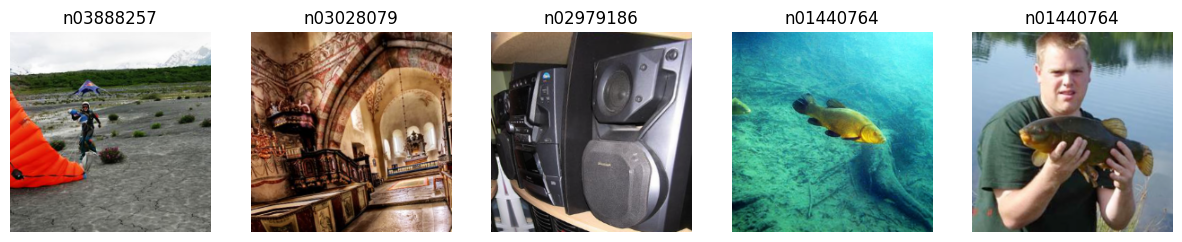

In [10]:
dls.show_batch(nrows=1, ncols=5)

The data is loaded, for now the batch size is 128, the image dimension is 128x128 and the color canal is RGB.

About the dataset itself, Imagenette 160 is a subset of Imagenette with only 10 different classes, the classe's ID format prevent confusion (when there is an homonym).

### 2.1 Building the architecture

According to Deep Residual Learning for Image Recognition, the resnet is made by alternating convolution and batch transformation. We will use the same structure than TP7.

In [ ]:
class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride, useBn = True):
      super().__init__()

      self.relu = nn.ReLU(inplace=True) #Will consume less space

      if not useBn :
        self.bn1 = nn.Identity()
        self.bn2 = nn.Identity()

      else :
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)

      self.conv1 = nn.Conv2d(in_channels, out_channels, 3, stride=stride, padding=1)
      self.conv2 = nn.Conv2d(out_channels, out_channels, 3, 1, 1)

      if stride == 2 or in_channels != out_channels :
        if not useBn : 
            self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)
        else :
          self.shortcut = nn.Sequential(
              OrderedDict([
              ("conv_shortcut", nn.Conv2d(in_channels, out_channels, 1, stride)),
              ("batch_norm_shortcut", nn.BatchNorm2d(out_channels)),
          ]))
      else :
        self.shortcut = nn.Sequential() #When there is no parameters it won't change anything (no changes on x)


    def forward(self, x) :
      s = self.shortcut(x)

      x = self.conv1(x)
      x = self.bn1(x)

      x = self.relu(x)

      x = self.conv2(x)
      x = self.bn2(x)

      return self.relu(x + s)

In [ ]:
class Bottleneck(nn.Module):
    def __init__(self, in_channels, out_channels, stride, useBn = True):
      super().__init__()

      self.relu = nn.ReLU(inplace=True) #Will consume less space
      mid_channels = out_channels // 4

      self.conv1 = nn.Conv2d(in_channels, mid_channels, 1)
      self.bn1 = nn.BatchNorm2d(mid_channels)

      self.conv2 = nn.Conv2d(mid_channels, mid_channels, 3, stride=stride, padding=1)
      self.bn2 = nn.BatchNorm2d(mid_channels)
      
      self.conv3 = nn.Conv2d(mid_channels, out_channels, 1)
      self.bn3 = nn.BatchNorm2d(out_channels)

      if stride == 2 or in_channels != out_channels :
        if not useBn : 
            self.shortcut = nn.Conv2d(in_channels, out_channels, 1, stride)
        else :
          self.shortcut = nn.Sequential(
              OrderedDict([
              ("conv_shortcut", nn.Conv2d(in_channels, out_channels, 1, stride)),
              ("batch_norm_shortcut", nn.BatchNorm2d(out_channels)),
          ]))
      else :
        self.shortcut = nn.Sequential() #When there is no parameters it won't change anything (no changes on x)


    def forward(self, x) :
      s = self.shortcut(x)

      x = self.conv1(x)
      x = self.bn1(x)

      x = self.relu(x)

      x = self.conv2(x)
      x = self.bn2(x)

      x = self.relu(x)

      x = self.conv3(x)
      x = self.bn3(x)

      return self.relu(x + s)

In [ ]:
class ResNet(nn.Module):
    def __init__(self, size, in_channels, useBn = True):
      super().__init__()

      if size not in configs :
        raise ValueError("This resnet's size is not valid")

      if size >= 50:
          block = Bottleneck
          self.expansion = 4
      else:
          block = ResBlock 
          self.expansion = 1

      self.relu = nn.ReLU(inplace=True) #Will consume less space aussi

      self.conv1 = nn.Conv2d(in_channels, 64, 7, 2, padding=3)
      
      if not useBn :
        self.bn1 = nn.Identity()
      else : 
        self.bn1 = nn.BatchNorm2d(64)

      self.maxPool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

      self.in_channel = 64
      
      #Après le stem, les in_channels sont toujours 64

      #Maintenant on initialise les layers

      self.layer1 = self._make_layer(block, 64 * self.expansion, configs[size][0], 1, useBn=useBn)
      self.layer2 = self._make_layer(block, 128 * self.expansion, configs[size][1], 2, useBn=useBn)
      self.layer3 = self._make_layer(block, 256 * self.expansion, configs[size][2], 2, useBn=useBn)
      self.layer4 = self._make_layer(block, 512 * self.expansion, configs[size][3], 2, useBn=useBn)

      self.avgPool = nn.AvgPool2d(kernel_size = 7) # I thin i can use adaptative pool but i will see later
      self.fc = nn.Linear(512 * self.expansion, 10) #10 = nombre de classes d'imagenette

    def _make_layer(self, block, out_channel, n, stride = 1, useBn = True):
      #Je mets block pour pouvoir mettre un resblock ou un bottle neck
      layers = []

      for i in range(n) :
        if i == 0 :
          #Si c'est le premier layer du bloc, il faudra modifier la stride (ça peut arriver)
          layers.append(block(self.in_channel, out_channel, stride, useBn))
          self.in_channel = out_channel
          #Pour que si on a diviser par 2 avec la stride ça marche bien
        else :
          layers.append(block(self.in_channel, out_channel, 1, useBn))

      return nn.Sequential(*layers)

    def forward(self, x) :

        x = self.conv1(x)
        x = self.bn1(x) #Si on a désactivé la batch norm, ce sera comme faire une multiplication par 1
        x = self.relu(x)
        x = self.maxPool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgPool(x)
        #Flatten pour passer de batchx512x1x1 à batchx512
        x = self.fc(torch.flatten(x, 1,3))

        return x

### Basic Testing

In [13]:
tenseurTest = torch.randn((12, 3, 224, 224))
resnet = ResNet(34, 3)
output = resnet(tenseurTest)
print(output.shape)

torch.Size([12, 10])


In [ ]:
def trainingModel(modele, dls, nbEpoch = 10, lr = 0.01, optimiser = "SGD", label_smoothing = 0.0, use_mixeup = False, alpha = 0.0, save_csv = None) :
  """ 
  alpha : parameters dictating the repartition of proportion of classes, alpha = 1.0 mean as much 50/50 images than 90/10


  """
  device = torch.device('cuda')
  modele = modele.to(device)

  if optimiser == "adam" :
    print("Using Adam")
    optimizer = torch.optim.Adam(modele.parameters(), lr = lr)
  else :
    optimizer = torch.optim.SGD(modele.parameters(), lr=lr, momentum = 0.9)
  #Sans momentum, l'accuracy oscille pas mal, du coup, plutôt que de manuellement tester les lr, je vais ajouter du momentum
  criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing) #By defaul it is 0.0

  if save_csv:
        with open(save_csv, mode='w', newline='') as file:
            writer = csv.writer(file)
            writer.writerow(['Epoch', 'Train_Loss', 'Val_Accuracy'])

  for i in range(nbEpoch) :
    modele.train()
    lossMoy = 0

    for x,y in dls.train :

      x = torch.tensor(x).to(device)
      y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU

      if use_mixeup :

        lambd = np.random.beta(alpha, alpha) #Using beta as mentionned in the article

        batch_size = x.size(0) #Using dls.bs may cause out of bound error if the number of image is not modulo bs

        index = torch.randperm(batch_size).to(device) # Creating a list of index from 0 to the size of the batch

        mixed_x = lambd * x + (1 - lambd) * x[index] #We create the batch with mixed data where the picture at the base index and the random are multiplied by lambda and 1-lambda 

        predictions = modele(mixed_x) # We get the prediction for those mixed up datas

        loss = lambd * criterion(predictions, y) + (1 - lambd) * criterion(predictions, y[index]) # We do the same as x but for y to get the good precision

      else :
        
        optimizer.zero_grad()

        predictions = modele(x)

        loss = criterion(predictions, y)

      #In both case i do the back propagation
      lossMoy += loss.item()

      loss.backward()

      optimizer.step()

  #Pour calculer l'accuracy à la fin de chaque epoch
    modele.eval()
    total_correct = 0
    with torch.no_grad():
      for x,y in dls.valid :
        x = torch.tensor(x).to(device)
        y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
        prediction_acc = modele(x)

        predictedClass = torch.argmax(prediction_acc, dim=1)

        correct = (predictedClass == y)

        total_correct += torch.sum(correct)

    train_loss = lossMoy/len(dls.train)
    valid_acc = (total_correct/len(dls.valid.dataset)).item()
    print(f"Epoch n°{i+1}, loss = {train_loss}, accuracy = {valid_acc}")

    if save_csv:
            with open(save_csv, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([i + 1, train_loss, valid_acc])


In [15]:
#I took different picture on google image and tried to apply it to my model.
def TestImage(monResnet) :
    
    img_pil = Image.open("Test_Golf.png").convert('RGB')

    transform = T.Compose([
        T.Resize((224, 224)),
        T.ToTensor(),
        T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    img_tensor = transform(img_pil).unsqueeze(0).to(torch.device('cuda'))

    monResnet.eval()
    with torch.no_grad():
        logits = monResnet(img_tensor)
        probs = torch.nn.functional.softmax(logits, dim=1)

    score_max, index_max = torch.max(probs, 1)
    confiance = score_max.item() * 100

    raw_id = dls.vocab[index_max.item()]
    real_name = get_name_from_id(raw_id)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_pil)
    plt.axis('off')
    plt.title(f"{real_name}\n Certainty : {confiance:.2f}%")
    plt.show()

#### Little test to see if everything is working fine

In [ ]:
model = ResNet(size=50, in_channels=3)

dummy_input = torch.randn(2, 3, 224, 224)

output = model(dummy_input)

print(output.shape) 

### Label smoothing

It consist in "smoothing" the result, basically, when we take a picture its labels are [0,0,0,1] where the 1 indicates its class.

When using label smoothing, we change the label's value using a factor $\epsilon$ where the distribution looks like [ $\frac{\epsilon}{K}$, $\frac{\epsilon}{K}$, $\frac{\epsilon}{K}$, $(1-\epsilon) + \frac{\epsilon}{K}$ ] with K the number of classes.

It changes the target, the optimal logit become a finite value $ z^*_y = \log\left(\frac{(K-1)(1-\epsilon)}{\epsilon}\right) + \alpha $, making it so that our model doesn't push it's weight to infinity, reducing overfitting.


### Mixup data augmentation 

Similar to label smoothing but now we "fuse" two images and the label become the proportion of the image [0,0,0.4,0.6] for example.

However, applying both label smoothing and mixup data augmentation may cause over-smoothing.

# Experimentation  
(I will write my results for different parameters)

Also, since the dataset in balanced and there is no hierarchy between classes, i consider that accuracy is a great metric to show the model's performance

## **Resnet-18, 100 Epochs, lr = 0.01, Batch Normalization = True/False**

*(The ResNet-18 with batch normalization will be my baseline)*

| Epoch | Baseline Loss | Baseline Acc | Loss (No Batch Norm) | Acc (No Batch Norm) |
| :---: | :-----------: | :-----------: | :------------------: | :------------------: |
| **1**   | 1.8016 | 0.4343 | 2.2747 | 0.1880 |
| **5**   | 0.9636 | 0.6596 | 1.8514 | 0.3890 |
| **25**  | 0.3626 | 0.8079 | 0.8772 | 0.7325 |
| **50**  | 0.2012 | 0.8408 | 0.4984 | 0.8229 |
| **98**  | 0.0599 | 0.8540 | 0.2187 | 0.8469 |
| **99**  | 0.0594 | 0.8683 | 0.2044 | 0.8400 |
| **100** | 0.0844 | 0.8206 | 0.1896 | 0.8270 |

Without batch normalization, the loss and accuracy at the start are worse, but the final accuracies are similar.  
The final loss is higher, meaning the model is less confident in its predictions.  
Overall, without batch normalization the model converges more slowly.

---

## **Now, with a different learning rate (lr = 0.1)**

*(With a greater learning rate, I want to check whether batch normalization helps stabilize the model.)*

### **Resnet-18, 100 Epochs, lr = 0.1, Batch Normalization = True**

| Epoch | Loss (No Batch Norm) | Acc (No Batch Norm) | Loss (With Batch Norm) | Acc (With Batch Norm) |
| :---: | :-------------------: | :-------------------: | :---------------------: | :---------------------: |
| **1**   | 2.2889 | 0.0993 | 2.8280 | 0.2280 |
| **5**   | 2.0140 | 0.3253 | 1.4821 | 0.5278 |
| **25**  | 0.8745 | 0.7258 | 0.6015 | 0.7320 |
| **50**  | 0.5178 | 0.7885 | 0.3202 | 0.8270 |
| **98**  | 0.2186 | 0.8468 | 0.0981 | 0.8499 |
| **99**  | 0.2044 | 0.8399 | 0.0916 | 0.8436 |
| **100** | 0.1896 | 0.8270 | 0.0924 | 0.8504 |

Batch normalization allows using a larger learning rate without divergence.

---

## **Changing Optimizer**

In the previous experiments, I used SGD with momentum 0.9.  
Now I will use **Adam**, which adapts the learning rate for each parameter.

### **Resnet-18, 100 Epochs, lr = 0.1 / 0.01**

| Epoch | Loss (lr = 0.1) | Acc (lr = 0.1) | Loss (With Batch Norm) | Acc (With Batch Norm) |
| :---: | :-------------: | :-------------: | :---------------------: | :---------------------: |
| **1**   | 3.2887 | 0.1903 | 2.8280 | 0.2280 |
| **5**   | 1.9388 | 0.3516 | 1.4821 | 0.5278 |
| **25**  | 0.9689 | 0.4958 | 0.6015 | 0.7320 |
| **50**  | 0.5540 | 0.7883 | 0.3202 | 0.8270 |
| **98**  | 0.2187 | 0.8469 | 0.0981 | 0.8499 |
| **99**  | 0.2044 | 0.8400 | 0.0916 | 0.8436 |
| **100** | 0.1896 | 0.8270 | 0.0924 | 0.8504 |

### Another Test

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\

Epoch n°1, loss = 2.358264531174751, accuracy = 0.23949043452739716
Epoch n°2, loss = 1.903505844612644, accuracy = 0.3554140031337738
Epoch n°3, loss = 1.707296954442377, accuracy = 0.43541398644447327
Epoch n°4, loss = 1.5329985667581427, accuracy = 0.49273881316185
Epoch n°5, loss = 1.3481618868161553, accuracy = 0.5462419986724854
Epoch n°6, loss = 1.2101782911444363, accuracy = 0.6354140043258667
Epoch n°7, loss = 1.0951999556528378, accuracy = 0.6463693976402283
Epoch n°8, loss = 0.993465977172329, accuracy = 0.5612738728523254
Epoch n°9, loss = 0.9222165909531999, accuracy = 0.6840763688087463
Epoch n°10, loss = 0.8915850961045043, accuracy = 0.6468789577484131
Epoch n°11, loss = 0.8193129064285591, accuracy = 0.6797451972961426
Epoch n°12, loss = 0.8096930507111223, accuracy = 0.6889171600341797
Epoch n°13, loss = 0.7344627641651729, accuracy = 0.7368152737617493
Epoch n°14, loss = 0.7148118949916265, accuracy = 0.7233120799064636
Epoch n°15, loss = 0.6769890197335857, accuracy

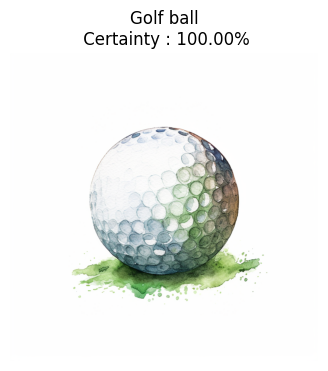

In [16]:
monResnet = ResNet(18, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.01, optimiser="adam", save_csv="Adam_Resnet18_lr0.01.csv")

TestImage(monResnet)

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\

Epoch n°1, loss = 1.8708209305593413, accuracy = 0.39312100410461426
Epoch n°2, loss = 1.4119180538882947, accuracy = 0.4598725736141205
Epoch n°3, loss = 1.1899594403293035, accuracy = 0.6374521851539612
Epoch n°4, loss = 1.1084260581290886, accuracy = 0.6078980565071106
Epoch n°5, loss = 1.0042430219584948, accuracy = 0.5197451710700989
Epoch n°6, loss = 0.9498744182390709, accuracy = 0.6710827946662903
Epoch n°7, loss = 0.8891465435289356, accuracy = 0.6924840211868286
Epoch n°8, loss = 0.8454703117070133, accuracy = 0.6820381879806519
Epoch n°9, loss = 0.7940354820800154, accuracy = 0.6338853240013123
Epoch n°10, loss = 0.7545035644753338, accuracy = 0.7121018767356873
Epoch n°11, loss = 0.7372136805972008, accuracy = 0.6929935812950134
Epoch n°12, loss = 0.7081554948467098, accuracy = 0.7464967966079712
Epoch n°13, loss = 0.6761271035018033, accuracy = 0.6545222401618958
Epoch n°14, loss = 0.6482796154610099, accuracy = 0.7391082644462585
Epoch n°15, loss = 0.6467462635203584, acc

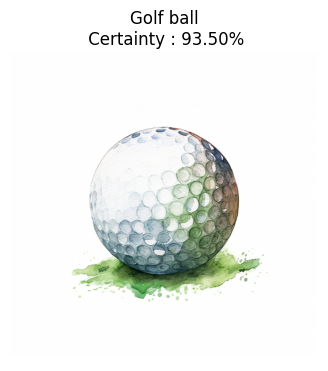

In [17]:
monResnet = ResNet(18, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.001, optimiser="adam", save_csv="Adam_Resnet18_lr0.001.csv")

TestImage(monResnet)

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\

Epoch n°1, loss = 2.4600393151583737, accuracy = 0.24535030126571655
Epoch n°2, loss = 2.0212831954433494, accuracy = 0.30547767877578735
Epoch n°3, loss = 1.8939608253844797, accuracy = 0.25426751375198364
Epoch n°4, loss = 1.7821651207257623, accuracy = 0.4122292697429657
Epoch n°5, loss = 1.5547146960480573, accuracy = 0.49477705359458923
Epoch n°6, loss = 1.4411058213612804, accuracy = 0.506242036819458
Epoch n°7, loss = 1.3362753146315274, accuracy = 0.4993630349636078
Epoch n°8, loss = 1.20379618504276, accuracy = 0.6048407554626465
Epoch n°9, loss = 1.1094264069648638, accuracy = 0.6285349726676941
Epoch n°10, loss = 1.0475437518668502, accuracy = 0.6453502774238586
Epoch n°11, loss = 0.9957473923082221, accuracy = 0.619108259677887
Epoch n°12, loss = 0.9316878057505986, accuracy = 0.693757951259613
Epoch n°13, loss = 0.8459800457301205, accuracy = 0.6952865719795227
Epoch n°14, loss = 0.8114508398591656, accuracy = 0.675159215927124
Epoch n°15, loss = 0.7787464326375151, accura

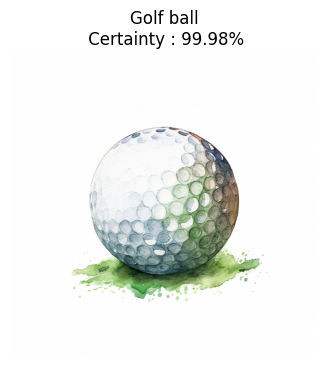

In [18]:
monResnet = ResNet(34, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.01, optimiser="adam", save_csv="Adam_Resnet34_lr0.01.csv")

TestImage(monResnet)

Using Adam


C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:29: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:30: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y).to(device)  #J'ai besoin de convertir pour pas avoir d'erreur avec le GPU
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\2858173774.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(x).to(device)
C:\Users\Maël\AppData\Local\Temp\ipykernel_11872\

Epoch n°1, loss = 1.9717221733641952, accuracy = 0.23949043452739716
Epoch n°2, loss = 1.5904085064587528, accuracy = 0.44076430797576904
Epoch n°3, loss = 1.3801337121284172, accuracy = 0.4794904291629791
Epoch n°4, loss = 1.2250446799683243, accuracy = 0.4163057208061218
Epoch n°5, loss = 1.145458850142074, accuracy = 0.481528639793396
Epoch n°6, loss = 1.0359507603188083, accuracy = 0.5319744944572449
Epoch n°7, loss = 0.9805551105982637, accuracy = 0.6341400742530823
Epoch n°8, loss = 0.9170316710864028, accuracy = 0.6394904255867004
Epoch n°9, loss = 0.8675846261520909, accuracy = 0.6998725533485413
Epoch n°10, loss = 0.8097514273369149, accuracy = 0.7360509037971497
Epoch n°11, loss = 0.7950013455462782, accuracy = 0.7319744825363159
Epoch n°12, loss = 0.739111354089763, accuracy = 0.7559235095977783
Epoch n°13, loss = 0.7423728684039965, accuracy = 0.7329936027526855
Epoch n°14, loss = 0.7117439271652535, accuracy = 0.7492993474006653
Epoch n°15, loss = 0.6515655056254505, accur

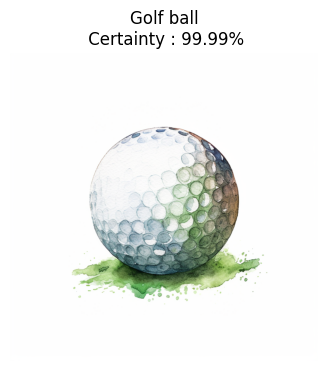

In [19]:
monResnet = ResNet(34, 3, useBn=True)

trainingModel(monResnet, dls, 100, 0.001, optimiser="adam", save_csv="Adam_Resnet34_lr0.001.csv")

TestImage(monResnet)

## Plotting performances 

### On Imagenette 160

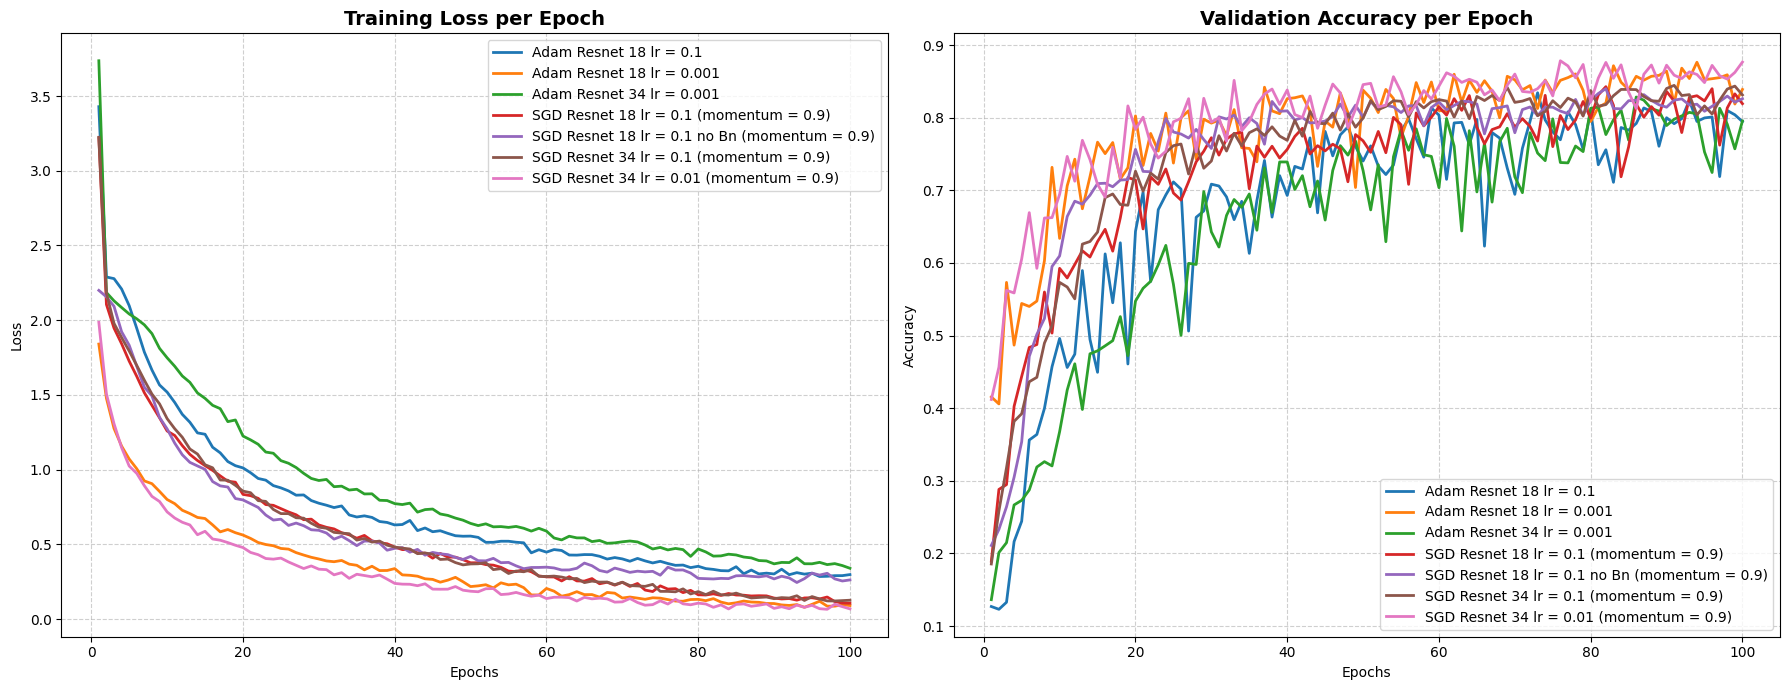

In [ ]:

files_map = {
    "Imagenette160\Adam_Resnet18_lr0.1.csv":"Adam Resnet 18 lr = 0.1",
    "Imagenette160\Adam_Resnet18_lr0.001.csv":"Adam Resnet 18 lr = 0.001",
    "Imagenette160\Adam_Resnet34_lr0.001.csv" : "Adam Resnet 34 lr = 0.001",
    "Imagenette160\SGD_Resnet18_moentum09_lr0.1.csv": "SGD Resnet 18 lr = 0.1 (momentum = 0.9)",
    "Imagenette160\SGD_Resnet18_moentum09_lr0.1NOBN.csv": "SGD Resnet 18 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette160\SGD_Resnet34_moentum09_lr0.1.csv": "SGD Resnet 34 lr = 0.1 (momentum = 0.9)",
    "Imagenette160\SGD_Resnet34_moentum09_lr0.01.csv": "SGD Resnet 34 lr = 0.01 (momentum = 0.9)"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2']

for i, (filename, label) in enumerate(files_map.items()):

    df = pd.read_csv(filename)

    color = colors[i % len(colors)]
    
    # Traçage de la Loss
    # On gère le cas où la loss est NaN (pour NOBN) pour que ça ne casse pas le graphe
    ax1.plot(df['Epoch'], df['Train_Loss'], label=label, color=color, linewidth=2)
    
    # Traçage de l'Accuracy
    ax2.plot(df['Epoch'], df['Val_Accuracy'], label=label, color=color, linewidth=2)
    
ax1.set_title('Training Loss per Epoch', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

ax2.set_title('Validation Accuracy per Epoch', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('comparaison_performance_resnet_160.png') 
plt.show()

For Imagenette 160, the best models are Adam on resnet 18 with lr = 0.001 and SGD with resnet 34 and lr = 0.01 (all SGD have a momentum of 0.9).

## On Imagenette 320

Graphique sauvegardé sous 'comparaison_performance_resnet_320.png'


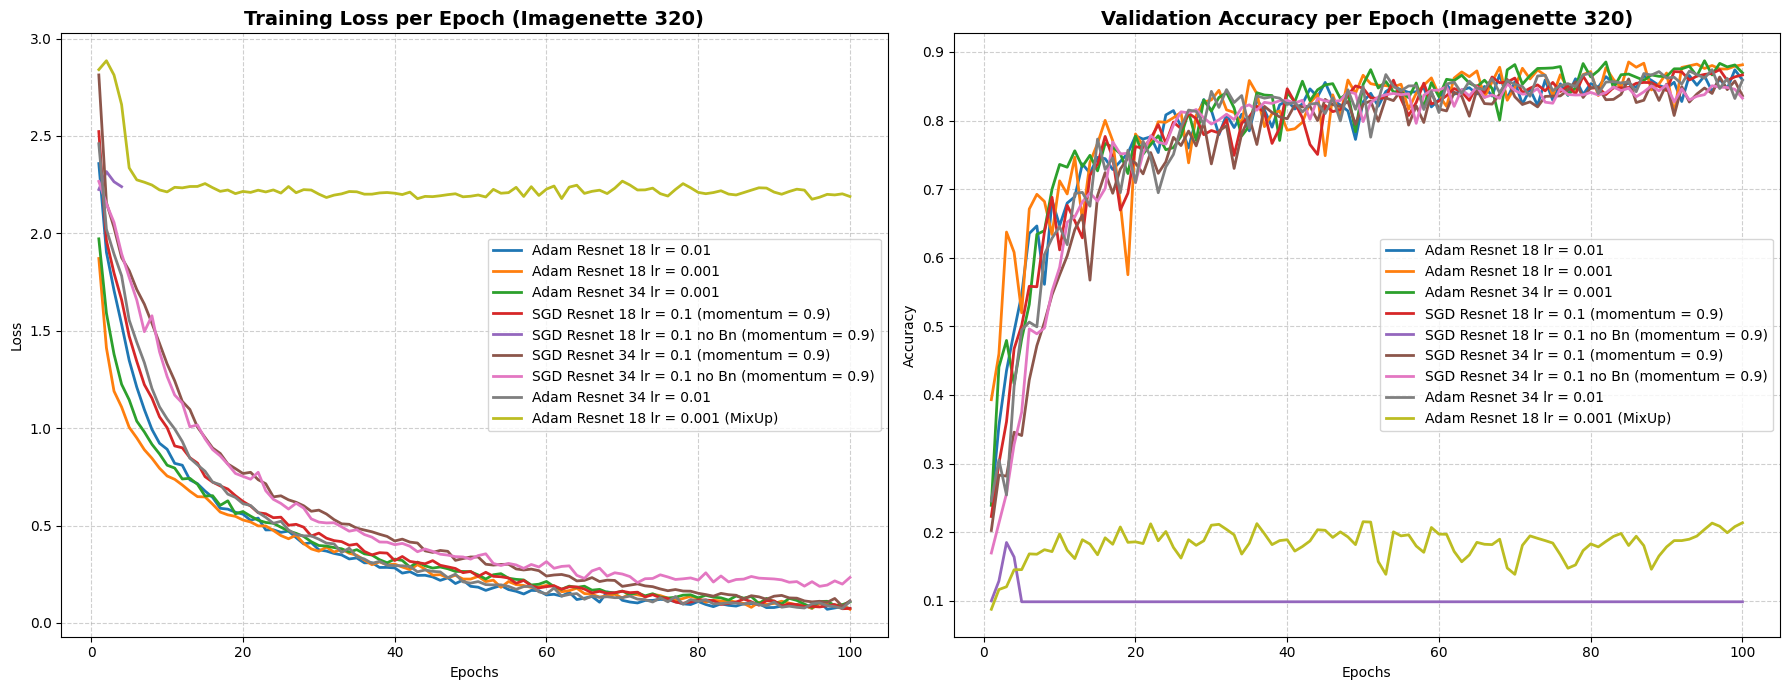

In [ ]:
files_map = {
    "Imagenette320\Adam_Resnet18_lr0.01.csv": "Adam Resnet 18 lr = 0.01",
    "Imagenette320\Adam_Resnet18_lr0.001.csv": "Adam Resnet 18 lr = 0.001",
    "Imagenette320\Adam_Resnet34_lr0.001.csv": "Adam Resnet 34 lr = 0.001",
    "Imagenette320\SGD_Resnet18_moentum09_lr0.1.csv": "SGD Resnet 18 lr = 0.1 (momentum = 0.9)",
    "Imagenette320\SGD_Resnet18_moentum09_lr0.1NOBN.csv": "SGD Resnet 18 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette320\SGD_Resnet34_moentum09_lr0.1.csv": "SGD Resnet 34 lr = 0.1 (momentum = 0.9)",
    "Imagenette320\SGD_Resnet34_moentum09_lr0.1NOBN.csv": "SGD Resnet 34 lr = 0.1 no Bn (momentum = 0.9)",
    "Imagenette320\Adam_Resnet34_lr0.01.csv": "Adam Resnet 34 lr = 0.01",
    "Imagenette320\Adam_Resnet18_lr0.001_MixUp.csv": "Adam Resnet 18 lr = 0.001 (MixUp)"
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Extended colors list to handle more files if needed
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

for i, (filename, label) in enumerate(files_map.items()):
    try:
        if os.path.exists(filename):
            df = pd.read_csv(filename)
            
            color = colors[i % len(colors)]
            
            # Traçage de la Loss
            ax1.plot(df['Epoch'], df['Train_Loss'], label=label, color=color, linewidth=2)
            
            # Traçage de l'Accuracy
            ax2.plot(df['Epoch'], df['Val_Accuracy'], label=label, color=color, linewidth=2)
        else:
            print(f"Fichier non trouvé: {filename}")
            
    except Exception as e:
        print(f"Erreur avec {filename}: {e}")

# Mise en forme du graphique de Loss
ax1.set_title('Training Loss per Epoch (Imagenette 320)', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.grid(True, linestyle='--', alpha=0.6)
ax1.legend()

# Mise en forme du graphique d'Accuracy
ax2.set_title('Validation Accuracy per Epoch (Imagenette 320)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.grid(True, linestyle='--', alpha=0.6)
ax2.legend()

plt.tight_layout()
plt.savefig('comparaison_performance_resnet_320.png')

## For the bag of tricks

I will keep imagenette 320 and use ____ and ______ as they showed better performances 